## Exercise III: Monte Carlo Simulation and Confidence Intervals [Total:30]

Let $U$ be uniformly distributed on $[0,1]$. You have to use Monte Carlo simulation to estimate the value of:
\begin{equation}
    \bar{f} = \mathbb{E}[f(U)],
\end{equation}
where $f(x)=x \cos(\pi x)$.



1.   Calculate analytically the exact value for $\bar{f}$ and $σ^2=\mathbb{E}[(f(U)-\bar{f})^2]$; show all the steps. **[5 Marks]**
2.   Write a Python function which computes
\begin{equation}
    Y_m = \frac{1}{N}\sum_{n=1}^{N} f(U^{(m,n)})
\end{equation}
for $1000$ different sets of $1000$ independent random variables $U^{(m,n)}$. **[5 Marks]**
3. Sort the $Y_m$ into ascending order, and then plot $C_m = (m-1/2)/1000$ versus $Y_m$ - this is the numerical cumulative distribution function. Superimpose on the same plot the cumulative distribution function you
would expect from the Central Limit Theorem and comment on your results. You may like to experiment by trying larger or smaller sets of points to
improve your understanding of the asymptotic behaviour described by
the CLT. **[6 Marks]**

4. Modify your code to use a single set of $10^{6}$ random numbers, and plot
\begin{equation}
    Y_{N} = N^{-1} \sum_{n=1}^{N} f(U^{(n)})
\end{equation}

versus $N$ for $N = 10^{3} - 10^{6}$.  This should demonstrate the convergence to the true value predicted by the Strong Law of Large Numbers. For each $N$, also compute an unbiased estimate for the variance $\sigma^2$ and hence add to the plot upper and lower confidence bounds based on 3 standard deviations of the variation in the mean. Add a line corresponding to the true value. Does this lie inside the bounds?**[6 Marks]**

5. Repeat points 1-4 for a European Call option in which the final value of the underlying is

\begin{equation}
    S(T) = S(0) \exp\left((r-\frac{1}{2}\sigma^2)T + \sigma W(T)\right)
\end{equation}

where $W(T)=\sqrt{T} X = \sqrt{T} Φ^{-1}(U)$, with $X$ being a unit Normal or $U$ a uniform $(0, 1)$ random variable. The payoff function is $f(s) = \exp(-r T)(S(T)-K)^{+}$ and the constants are $r = 0.05, \sigma=0.2, S(0)=100, K=100$.

There is no need to compute the analytic variance in part 1.; just use the
unbiased estimator when plotting the CLT prediction in part 4. The code for computing the price of the European Call option is provided here below.**[8 Marks]**


# 3.1

$$
E(f(x))=\int_0^1f(x) dx=\int_0^1x cos(\pi x) dx
$$

To integrate this, I will use integration by parts where $u=x$ and $dv=cos(\pi x)dx$ where
$$
\int_0^1udv = [uv]_0^1- \int_0^1vdu
$$
So $du=dx$ and $v=\frac{1}{\pi}sin(\pi x)$

Hence, we get:
$$
\int_0^1x cos(\pi x) dx = [x\frac{1}{\pi}sin(\pi x)]_0^1- \int_0^1 \frac{1}{\pi} sin(\pi x)  dx
$$

The first part: $[x\frac{1}{\pi}sin(\pi x)]_0^1= 0-0=0$

The second part: $$- \int_0^1 \frac{1}{\pi} sin(\pi x)  dx \\= [\frac{1}{\pi^2}cos(\pi x)]^1_0\\= \frac{1}{\pi^2}[-1-1]= \frac{-2}{\pi^2}\approx -0.202642$$

We will now find the variance
$$
\mathbb{E}\big[(f(u)-\bar f)^2\big] 
= \mathbb{E}(f^2) - \mathbb{E}(f)^2 \\
= \mathbb{E}(f^2) - \left(\frac{2}{\pi^2}\right)^2
$$

We will now find $\mathbb{E}(f^2)$

\begin{align}
\mathbb{E}(f^2)
&= \int_0^1 x^2\cos^2(\pi x)\,dx
\end{align}

Using the identity

$$
\cos^2(\pi x) = \frac{1+\cos(2\pi x)}{2}
$$

\begin{align}
\int_0^1 x^2\cos^2(\pi x)\,dx
&= \int_0^1 x^2 \frac{1+\cos(2\pi x)}{2}\,dx \\
&= \frac{1}{2}\int_0^1 x^2\,dx + \frac{1}{2}\int_0^1 x^2\cos(2\pi x)\,dx
\end{align}

\begin{align}
\frac{1}{2}\int_0^1 x^2\,dx
&= \frac{1}{2}\left[\frac{x^3}{3}\right]_0^1 \\
&= \frac{1}{6}
\end{align}


For the second term use **integration by parts**

$$
u = x^2, \qquad dv = \cos(2\pi x)\,dx
$$

Then

$$
v = \frac{1}{2\pi} sin(2\pi x)\\
du = 2xdx 
$$

So

$$
\int_0^1 x^2\cos(2\pi x)\,du
= \Big[uv\Big]_0^1 - \int_0^1 v\,dx \\
= [x^2 \frac{1}{2\pi} sin(2\pi x)]_0^1 - \int_0^1 \frac{1}{2\pi} sin(2\pi x)2xdx
$$
for $[x^2 \frac{1}{2\pi} sin(2\pi x)]_0^1=0-0=0$

While for $$- \frac{1}{\pi} \int_0^1  sin(2\pi x)xdx $$ 
we use integration by parts one final time where $u=x$ and $dv=sin(2\pi x)$, so $du=dx$ and $v= -\frac{1}{2 \pi}cos(2\pi x)$

$$ \int_0^1  sin(2\pi x)xdx
= \Big[uv\Big]_0^1 - \int_0^1 v\,dx \\
= [-x \frac{1}{2 \pi}cos(2\pi x)]_0^1 + \int_0^1 \frac{1}{2 \pi}cos(2\pi x)dx \\
= -\frac{1}{2 \pi} + [\frac{1}{(2 \pi)^2}sin(2\pi x)]^1_0 \\
= -\frac{1}{2 \pi} + [\frac{1}{(2 \pi)^2}sin(2\pi x)]^1_0 \\
= -\frac{1}{2 \pi} 
$$
So we get that
$$
-\frac{1}{\pi}\int_0^1  sin(2\pi x)xdx = \frac{1}{2 \pi^2} 
$$

Which again gives us
$\frac{1}{2}\int_0^1 x^2\cos(2\pi x)\,dx= -\frac{1}{4\pi}$

We finally combine everything, which gives us

$$
\mathbb{E}(f^2) = \int_0^1 x^2\cos^2(\pi x)\,dx = \frac{1}{6}+ \frac{1}{2 \pi^2} 
$$

Consequently, the variance will be given as
$$
\mathbb{E}\big[(f(u)-\bar f)^2\big] = \mathbb{E}(f^2) - \left(\frac{2}{\pi^2}\right)^2 \\
= \frac{1}{6}+ \frac{1}{2 \pi^2}- \left(\frac{2}{\pi^2}\right)^2 \\
= \frac{1}{6}+ \frac{1}{2 \pi^2}- \left(\frac{4}{\pi^4}\right) \\
= \frac{\pi^4+ 3\pi^2- 24}{6\pi^4} \\
\approx 0.17626
$$


In [1]:
# all packages and helper functions (not the directly answering the main question) can be found in helper_functions_1_2_3.py:
from helper_functions_1_2_3 import *
from ploting_functions import *

### 3.2
We have written a python function for 1000 sets with 1000 observations within each set. $Y_m$ is drawn from a normal distribution due to CLT. 

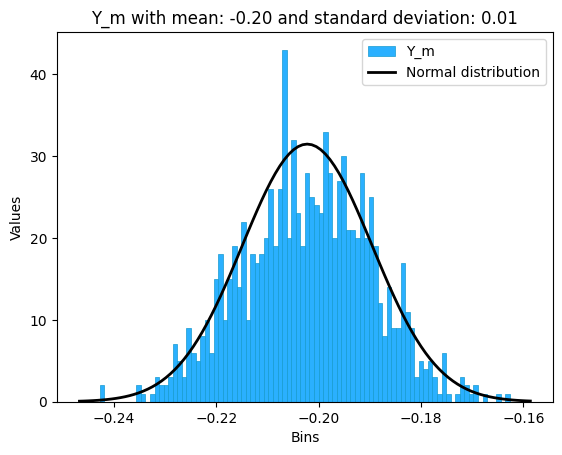

In [2]:
## 3.2
# input data
Y_m = exercise_3_2()
# Plot histogram
plot_hist_3(Y_m)


### 3.3
In the figure below, we can see have how $m$ and $n$ impacts the numerical cumulative distribution.

As $m$ increases, the numerical cumulative distribution becomes smoother, for $M=100$ it is quite bumpy, while for $m=10,000$ it follows the normal distribution perfectly. This is because
\begin{align}
    Y_m =\frac{1}{N}\sum_{n=1}^Nf(U^{(m,n)}
\end{align}
As $Y_m$ is the mean over N observations, $Y_m$ will according to the CLT follow a normal distribution. As $m$ increases, we will increase our draws from the normal distirbution. When $m$ is relatively small, there will be noise. However, as $m$ increases the numerical distributino will begin to mirror the distribution of $Y_m$.

As $N$ increases, the distribution of $Y_m$ will go towards a normal distribution. As $N$ increases, the variance of the distirbution of $Y_m$ collapses as it is defined as $Var(Y_m)=\frac{\sigma}{\sqrt{N}}$. This is why the x-axis is squeezed as $N$ increases. If $N$ is small, there is a higher risk that outliers will dominate $Y_m$. 

Consequently, $N$ is important to ensure that $Y_m$ converges towards a normal distribution and that the CLT is true. The size of $M$ does not impact the CLT, but as $M$ increases $\{Y_m\}_{m=1}^M$, we can better map the distribution of $Y_m$.

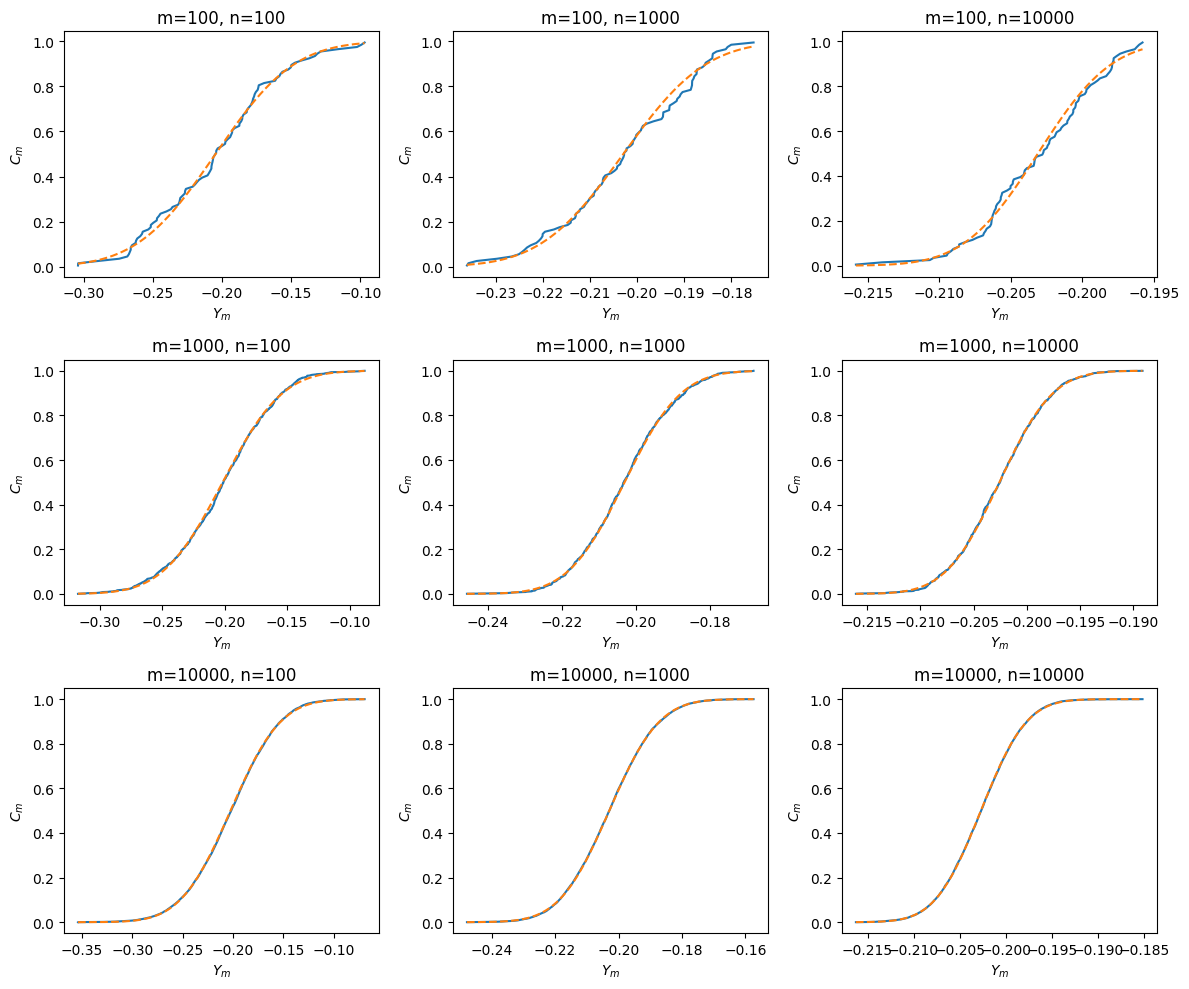

In [3]:
m_vals = [100, 1000, 10000]
n_vals = [100, 1000, 10000]
plot_grid_3_3(m_vals, n_vals)

### 3.4
We have computed the true analytical value, the unbiased estimate of $Y_N$, and the unbiased estimate of $\sigma^2$ for the confidence ban in Figure below. 
First, as N increases in the beginning, $Y_N$ quickly begins to circulate around the true value of $Y_N$. However, in the beginning there is a high variance of the estimate. As $N$ increases, the deviation between the true value and the estimate of $Y_N$ will generally fall along with the variance. When $N$ is extremely high around $10^6$, there are still fluctuations in the estimate in $Y_N$. However, the scale is extremely small as $Y_N$ is collapsing around the true value. 

As the confidence bounds is $\pm 3 \sigma$ and $Y_N$ follows a normal distribution, in theory $Y^{true}_N$  will be within the bounds $99.73 \%$ of the times under the i.i.d. assumption. Our $Y^{true}_N$ is within the confidence bounds $99.89\%$ of the times. 

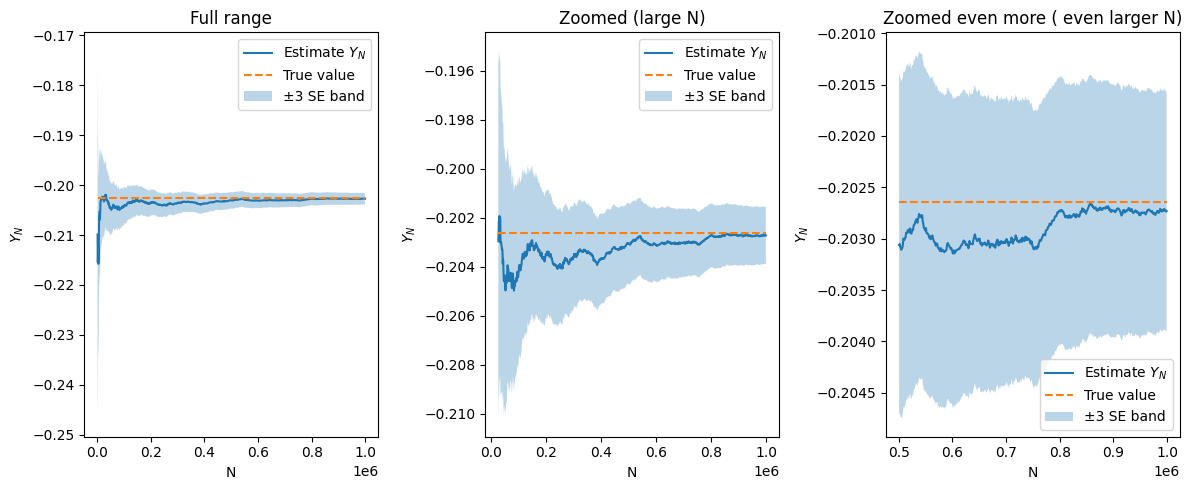

In [4]:
### 3.4 
def exercise_3_4(m=10**6, n=1, step_n = 1_000):
    U = rng.uniform(size=(m, n))
    f_u = f_ex_3(U)
    y_m_list, std_list  = [], []
    N_val = range(step_n, m, step_n)
    for i in N_val:
        y_m_list.append(np.mean(f_u[:i,:]))
        std_list.append(np.std(f_u[:i,:], ddof=1)/ np.sqrt(i))
        
    return np.array(y_m_list), np.array(std_list), np.array(list(N_val))

step_n = 1_000
y_m_list, std_list, N_val  = exercise_3_4(step_n = step_n)
plot_3_4(y_m_list, std_list, N_val)

### 3.5

In [5]:
m,n = 1000, 1000
r=0.05
sigma=0.2
T=1
S=100
K=100
opt='value'

def f_for_european(W, r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value'):
    S_T = S* np.exp((r-0.5*sigma**2)*T+sigma*W)
    return np.exp(-r*T)*np.maximum(S_T-K,0)

def mc_mean_var_3_5(sim_european):
    return np.mean(sim_european,axis=0), np.std(sim_european, ddof=1, axis=0)

U = rng.uniform(size=(m, n))
X = scipy.stats.norm.ppf(U)
W = np.sqrt(T)*X
true_european = european_call(r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value')
sim_european = f_for_european(W)
mc_euro_mean, mc_euro_std = mc_mean_var_3_5(sim_european)


The importance of $M$ and $N$ is the same as in question 3.3 as we take the mean of the $N$ different observations. The only difference is the center of $Y_{M,N}^S$, which is the MC estimate of $S(T)$, has been drifted tot he right. The CLT will be true for any transformation over observations when taking the mean at the end.

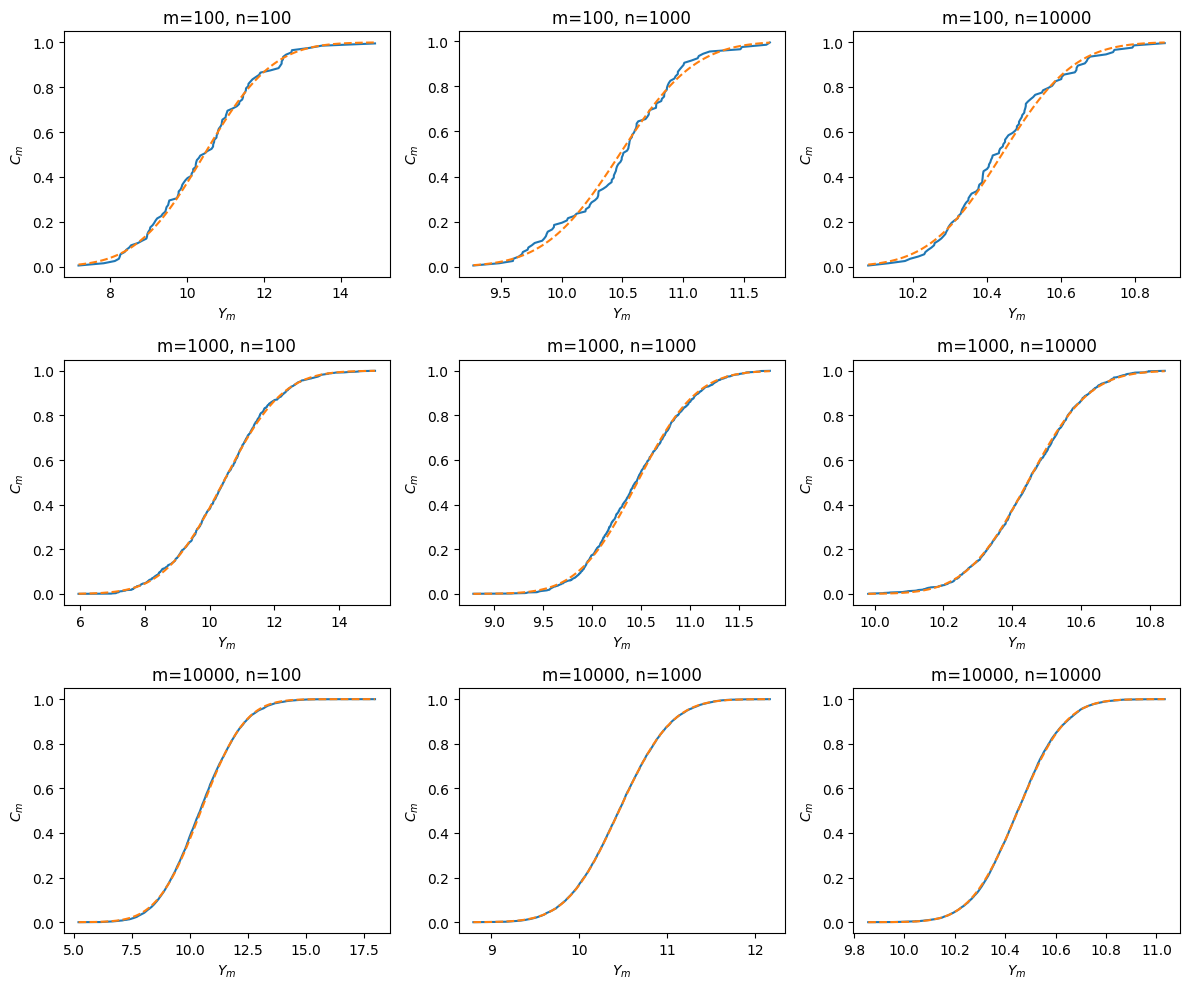

In [6]:
# 3.5.3
m_vals = [100, 1000, 10000]
n_vals = [100, 1000, 10000]
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for i, m in enumerate(m_vals):
    C_m_test = [(k - 0.5)/m for k in range(1, m+1)]
    for j, n in enumerate(n_vals):
        U = rng.uniform(size=(n, m))
        X = scipy.stats.norm.ppf(U)
        W = np.sqrt(T)*X
        true_european = european_call(r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value')
        sim_european = f_for_european(W)
        mc_euro_mean, mc_euro_std = mc_mean_var_3_5(sim_european)
        y_grid = np.linspace(mc_euro_mean.min(), mc_euro_mean.max(), m)

        mc_euro_mean.sort()
        mu = np.mean(mc_euro_mean)
        sigma = np.std(mc_euro_mean)
        F_clt = norm_cdf((y_grid-mu)/sigma)

        ax = axes[i, j]
        ax.plot(mc_euro_mean, C_m_test, label='Numerical CDF')
        ax.plot(y_grid, F_clt, '--', label='CLT CDF')
        ax.set_title(f"m={m}, n={n}")
        ax.set_xlabel("$Y_m$")
        ax.set_ylabel("$C_m$")

plt.tight_layout()
plt.show()


In [7]:
# 3.5.4
### 3.4 
def exercise_3_5_4(n=10**6, m=1, step_n = 1_000):
    U = rng.uniform(size=(n, m))
    X = scipy.stats.norm.ppf(U)
    W = np.sqrt(T)*X
    sim_european = f_for_european(W)

    mc_european_list, std_euro_list  = [], []
    N_euro_val = range(step_n, n, step_n)
    for i in N_euro_val:
        mc_european_list.append(np.mean(sim_european[:i],axis=0))
        std_euro_list.append(np.std(sim_european[:i], ddof=1,axis=0)/ np.sqrt(i))
        
        
    return np.array(mc_european_list), np.array(std_euro_list), np.array(list(N_euro_val))

step_n = 1_000
mc_european_list, std_euro_list, N_euro_val  = exercise_3_5_4(step_n = step_n)


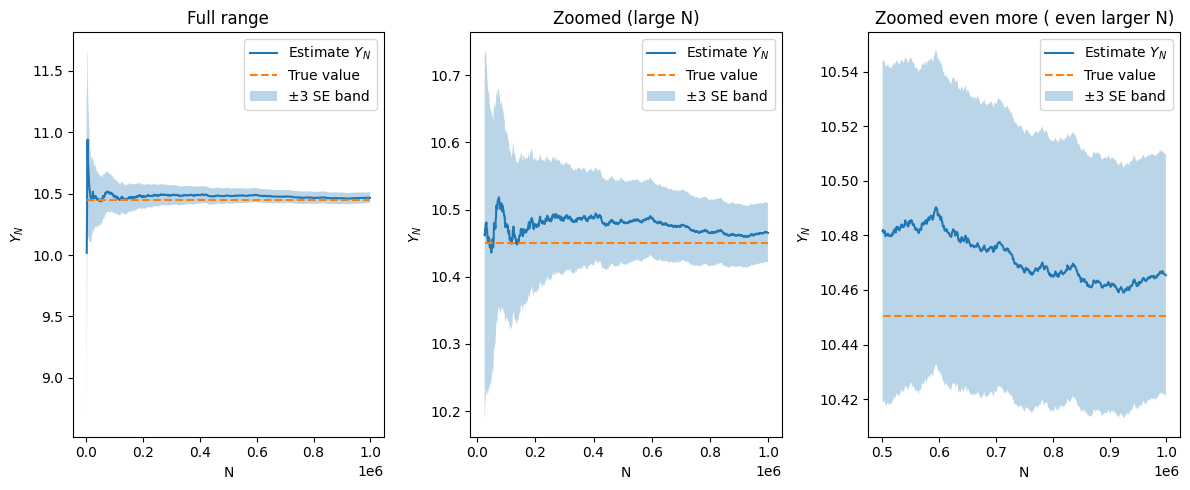

In [8]:
plot_3_5_2(true_european, mc_european_list, std_euro_list, N_euro_val)